# Truth $\delta$ALK / $\delta$DIC maps

Like `deltaDIC_deltaALK.ipynb`, but truth fields only — no CDR tracer reconstruction alongside. `plot_truth_panel(date, exp)` draws a 1$\times$3 panel: $\delta$ALK from the OAE experiment, $\delta$DIC from the OAE experiment, and $\delta$DIC from the DOR experiment, for the given `exp` (location + amplitude, e.g. `"JP8"`) and `date`.

In [13]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from roms_tools import Grid, ROMSOutput
from plot import _finish_panel, _plot_colorbar, get_label_string, compute_zoom_box, _draw_zoom_box, ZOOM_COORDS, DEFAULT_ZOOM_CITIES

In [14]:
grid_file = "roms_marbl_dic/expCTRL/pacmed12_grd.nc"
grid = Grid.from_file(grid_file, theta_s=6.0, theta_b=6.0, hc=250.0, N=100)

2026-09-14 04:55:46 - INFO - === Preparing the vertical coordinate system using N = 100, theta_s = 6.0, theta_b = 6.0, hc = 250.0 ===
2026-09-14 04:55:46 - INFO - Total time: 0.003 seconds
2026-09-14 04:55:46 - INFO - ================================================================================================


In [15]:
# Release centers from grid indices defined in make_tracer_surface_flux.ipynb
_release_indices = {
    "JP": (710, 459),
    "VI": (855, 1135),
    "BC": (650, 1290),
    "EC": (490, 1640),
}
release_centers = {
    loc: (float(grid.ds["lon_rho"][eta, xi]), float(grid.ds["lat_rho"][eta, xi]))
    for loc, (eta, xi) in _release_indices.items()
}

## Configuration

In [16]:
locations = {
    "VI": {
        "name": "Vancouver Island",
        "zoom_coords": ZOOM_COORDS["VI"],
    },
    "BC": {
        "name": "Baja California",
        "zoom_coords": ZOOM_COORDS["BC"],
    },
    "EC": {
        "name": "Ecuador",
        "zoom_coords": ZOOM_COORDS["EC"],
    },
    "JP": {
        "name": "Japan",
        "zoom_coords": ZOOM_COORDS["JP"],
    },
}

amp_labels = {"10": "10", "7": "100", "8": "1000"}

scenarios = {
    "dor": {
        "marbl_dir": "roms_marbl_dic",
        "ctrl_subdir": "OUTPUT_dor",
        "title": "DOR",
        "exps": {
            "JP10": {"label": r"\mathrm{J10}\!\ominus"},
            "JP7":  {"label": r"\mathrm{J100}\!\ominus"},
            "JP8":  {"label": r"\mathrm{J1000}\!\ominus"},
            "VI10": {"label": r"\mathrm{V10}\!\ominus"},
            "VI7":  {"label": r"\mathrm{V100}\!\ominus"},
            "VI8":  {"label": r"\mathrm{V1000}\!\ominus"},
            "BC10": {"label": r"\mathrm{B10}\!\ominus"},
            "BC7":  {"label": r"\mathrm{B100}\!\ominus"},
            "BC8":  {"label": r"\mathrm{B1000}\!\ominus"},
            "EC10": {"label": r"\mathrm{E10}\!\ominus"},
            "EC7":  {"label": r"\mathrm{E100}\!\ominus"},
            "EC8":  {"label": r"\mathrm{E1000}\!\ominus"},
        },
    },
    "oae": {
        "marbl_dir": "roms_marbl_alk",
        "ctrl_subdir": "OUTPUT_oae_perlmutter",
        "title": "OAE",
        "exps": {
            "JP10": {"label": r"\mathrm{J10}\!\oplus"},
            "JP7":  {"label": r"\mathrm{J100}\!\oplus"},
            "JP8":  {"label": r"\mathrm{J1000}\!\oplus"},
            "VI10": {"label": r"\mathrm{V10}\!\oplus"},
            "VI7":  {"label": r"\mathrm{V100}\!\oplus"},
            "VI8":  {"label": r"\mathrm{V1000}\!\oplus"},
            "BC10": {"label": r"\mathrm{B10}\!\oplus"},
            "BC7":  {"label": r"\mathrm{B100}\!\oplus"},
            "BC8":  {"label": r"\mathrm{B1000}\!\oplus"},
            "EC10": {"label": r"\mathrm{E10}\!\oplus"},
            "EC7":  {"label": r"\mathrm{E100}\!\oplus"},
            "EC8":  {"label": r"\mathrm{E1000}\!\oplus"},
        },
    },
}

## Load data

In [17]:
def parse_exp(exp):
    """Split e.g. \"JP8\" into location key \"JP\" and amplitude \"8\"."""
    return exp[:2], exp[2:]


def load_truth(date, scenario_key, exp):
    """Load the marbl output for a single exp (no control run needed — truth fields only)."""
    scen = scenarios[scenario_key]
    _, amp = parse_exp(exp)
    # roms_marbl_alk's amp=8 site dirs are currently named exp<SITE>8_perlmutter
    # (Anvil-sourced copies without the suffix aren't reliable yet).
    suffix = "_perlmutter" if scen["marbl_dir"] == "roms_marbl_alk" and amp == "8" else ""
    roms_output = ROMSOutput(
        grid=grid,
        path=f"{scen['marbl_dir']}/exp{exp}{suffix}/OUTPUT/JOINED/pacmed_bgc.{date}*.nc",
        use_dask=True,
    )
    return roms_output.ds


def compute_truth_delta(ds, tracer="dic"):
    s_rho = -1
    if tracer == "alk":
        return (ds.ALK - ds.ALK_ALT_CO2).isel(s_rho=s_rho).squeeze().compute()
    else:
        return (ds.DIC - ds.DIC_ALT_CO2).isel(s_rho=s_rho).squeeze().compute()

## Core functions

In [18]:
DEFAULT_CMAPS = {"alk_oae": "OrRd", "dic_oae": "BuGn", "dic_dor": "BuPu_r"}


def auto_field_kwargs(data, key=None):

    data_min = float(data.min(skipna=True))
    data_max = float(data.max(skipna=True))
    if abs(data_min) > abs(data_max):
        kw = {"vmin": data_min, "vmax": 0}
    else:
        kw = {"vmin": 0, "vmax": data_max}
    if key is not None:
        kw["cmap"] = DEFAULT_CMAPS[key]
    return kw


def plot_map_panel(fig, ax, lon, lat, data, zoom_coords, kwargs_plot,
                   shrink=0.7, pad=0.15, vpos=0.05, title="",
                   loc=None, release_centers=None, zoom_box=None, cities=None):
    mask = grid.ds.mask_rho
    masked_data = data.where(mask)
    p = ax.pcolormesh(lon, lat, masked_data,
                      transform=ccrs.PlateCarree(), **kwargs_plot)
    vmin, vmax = kwargs_plot.get("vmin"), kwargs_plot.get("vmax")
    # vmin/vmax always straddle 0 (auto_field_kwargs -- or a kwargs_override -- pins one of
    # them to exactly 0 as a fixed sign boundary, not a data-driven clip), so only the
    # non-zero side should ever grow an extend arrow; otherwise floating-point noise right
    # at 0 draws a spurious arrow on the zero side.
    if vmin == 0:
        extend = "max" if vmax is not None and float(data.max()) > vmax else "neither"
    elif vmax == 0:
        extend = "min" if vmin is not None and float(data.min()) < vmin else "neither"
    else:
        extend = None
    _plot_colorbar(fig, ax, p, data, vmax, vmin,
                   label=r"mmol/m$^3$", shrink=shrink, pad=pad, extend=extend)
    label_string = get_label_string(data)
    ax.text(0.5, vpos, label_string,
            transform=ax.transAxes, ha="center", va="center")
    if title:
        ax.set_title(title)
    _finish_panel(
        ax, zoom_coords["lon_min"], zoom_coords["lon_max"],
        zoom_coords["lat_min"], zoom_coords["lat_max"],
        loc, release_centers, cities,
    )
    if zoom_box is not None:
        _draw_zoom_box(ax, *zoom_box)


def plot_truth_panel(date, exp, kwargs_override=None, release_centers=None,
                     figsize=None, shrink=0.8, pad=0.12, vpos=0.05,
                     panel_labels=("a", "b", "c"), panel_labels_zoom_row=("d", "e", "f"),
                     zoom_row=False, zoom_half_width_km=400, zoom_row_cities=None):
    """1x3 (or 2x3) panel of truth deltas for a single date/exp: OAE ALK, OAE DIC, DOR DIC.

    Colormaps are fixed via DEFAULT_CMAPS (alk_oae: OrRd, dic_oae: BuPu, dic_dor: BuGn_r).
    kwargs_override is keyed by "alk_oae", "dic_oae", "dic_dor" and overrides the auto
    vmin/vmax for that panel, e.g. {"dic_dor": dict(vmin=-3, vmax=0)}. A cmap key may
    still be passed to override the default for that panel.
    release_centers : dict, optional
        Maps loc -> (lon, lat) for the X marker and a circle overlay enclosing 90% of that
        site's actual Gaussian release footprint (see plot.py: RELEASE_SIGMA_KM), drawn on
        the first and last panel only (OAE ALK and DOR DIC) in the first row.
    zoom_row : bool, optional
        Add a second row with a `zoom_half_width_km`-wide zoomed-in view of all three panels
        around the release center (release marker/circle shown on all three), with the
        zoomed subregion dashed on the corresponding first-row panel. Defaults to True for
        Vancouver Island ("VI"), False otherwise; pass True/False explicitly to override.
    zoom_row_cities : list or dict, optional
        Cities to mark (dot + label) on the zoom row only, passed through to
        plot.py's _draw_city_markers. Defaults to DEFAULT_ZOOM_CITIES.get(loc_key)
        (e.g. Vancouver/Victoria/Port Hardy for "VI"); pass False to suppress.
    """
    loc_key, amp = parse_exp(exp)
    if zoom_row and not (release_centers and loc_key in release_centers):
        zoom_row = False
    if zoom_row_cities is None:
        zoom_row_cities = DEFAULT_ZOOM_CITIES.get(loc_key)

    zoom = locations[loc_key]["zoom_coords"]
    lon, lat = grid.ds["lon_rho"], grid.ds["lat_rho"]

    proj = ccrs.LambertConformal(
        central_longitude=(zoom["lon_min"] + zoom["lon_max"]) / 2,
        central_latitude=(zoom["lat_min"] + zoom["lat_max"]) / 2,
    )

    dor_ds = load_truth(date, "dor", exp)
    oae_ds = load_truth(date, "oae", exp)

    delta_dic_dor = compute_truth_delta(dor_ds, tracer="dic")
    delta_alk_oae = compute_truth_delta(oae_ds, tracer="alk")
    delta_dic_oae = compute_truth_delta(oae_ds, tracer="dic")

    label_dor = scenarios["dor"]["exps"][exp]["label"]
    label_oae = scenarios["oae"]["exps"][exp]["label"]


    titles0 = (
        rf"${label_oae}$: $\delta \mathrm{{ALK}}$",
        rf"${label_oae}$: $\delta \mathrm{{DIC}}$",
        rf"${label_dor}$: $\delta \mathrm{{DIC}}$",
    )
    if panel_labels:
        titles = tuple(f"({label}) {title}" for label, title in zip(panel_labels, titles0))
        
    titles_zoom_row = tuple(f"({label}) {title}" for label, title in zip(panel_labels_zoom_row, titles0))
        
    panels = [
        ("alk_oae", delta_alk_oae, titles[0], release_centers, titles_zoom_row[0]),
        ("dic_oae", delta_dic_oae, titles[1], None, titles_zoom_row[1]),
        ("dic_dor", delta_dic_dor, titles[2], release_centers, titles_zoom_row[2]),
    ]

    nrows = 2 if zoom_row else 1
    if figsize is None:
        figsize = (12, 8) if zoom_row else (12, 4)
    fig, axs = plt.subplots(nrows, 3, figsize=figsize, subplot_kw={"projection": proj})
    axs = np.atleast_2d(axs)

    zoom_box, zoom_sub = None, None
    if zoom_row:
        lon_min, lon_max, lat_min, lat_max = compute_zoom_box(release_centers[loc_key], zoom_half_width_km)
        zoom_box = (lon_min, lon_max, lat_min, lat_max)
        zoom_sub = {"lon_min": lon_min, "lon_max": lon_max, "lat_min": lat_min, "lat_max": lat_max}

    for col, (key, data, title, panel_release_centers, title_zoom_row) in enumerate(panels):
        kw = {**auto_field_kwargs(data, key), **(kwargs_override[key] if kwargs_override and key in kwargs_override else {})}
        plot_map_panel(fig, axs[0, col], lon, lat, data, zoom, kw,
                       shrink=shrink, pad=pad, vpos=vpos, title=title,
                       loc=loc_key, release_centers=panel_release_centers,
                       zoom_box=zoom_box)
        
        if zoom_row:
            kw_zoom_row = auto_field_kwargs(data, key)
            plot_map_panel(fig, axs[1, col], lon, lat, data, zoom_sub, kw_zoom_row,
                           shrink=shrink, pad=pad, vpos=vpos, title=title_zoom_row,
                           release_centers=panel_release_centers,
                           loc=loc_key, cities=zoom_row_cities)

    plt.tight_layout()
    return fig

In [19]:
def plot_dalk_two_panel(date, exps, kwargs_override=None, release_centers=None,
                        figsize=(12, 4), shrink=0.8, pad=0.12, vpos=0.05,
                        panel_labels=("j", "k")):
    """1x3 panel showing only OAE delta-ALK truth maps for two experiments, side by side.

    Same overall figure dimensions as `plot_truth_panel`'s 1x3 layout, but only the first
    two panels are filled (one per exp in `exps`); the third panel is left blank.
    kwargs_override is keyed by exp (e.g. "BC8") and overrides the auto vmin/vmax/cmap
    for that panel.
    """
    lon, lat = grid.ds["lon_rho"], grid.ds["lat_rho"]
    fig = plt.figure(figsize=figsize)
    
    for col, exp in enumerate(exps):
        loc_key, amp = parse_exp(exp)
        zoom = locations[loc_key]["zoom_coords"]
        proj = ccrs.LambertConformal(
            central_longitude=(zoom["lon_min"] + zoom["lon_max"]) / 2,
            central_latitude=(zoom["lat_min"] + zoom["lat_max"]) / 2,
        )
        ax = fig.add_subplot(1, 3, col + 1, projection=proj)  # positions 2 and 3

        oae_ds = load_truth(date, "oae", exp)
        delta_alk_oae = compute_truth_delta(oae_ds, tracer="alk")
        label_oae = scenarios["oae"]["exps"][exp]["label"]
        title = rf"({panel_labels[col]}) ${label_oae}$: $\delta \mathrm{{ALK}}$"

        kw = {**auto_field_kwargs(delta_alk_oae, "alk_oae"),
              **(kwargs_override[exp] if kwargs_override and exp in kwargs_override else {})}
        plot_map_panel(fig, ax, lon, lat, delta_alk_oae, zoom, kw,
                       shrink=shrink, pad=pad, vpos=vpos, title=title,
                       loc=loc_key, release_centers=release_centers)

    ax_blank = fig.add_subplot(1, 3, 3)
    ax_blank.axis("off")
    
    plt.tight_layout()
    return fig

## Japan

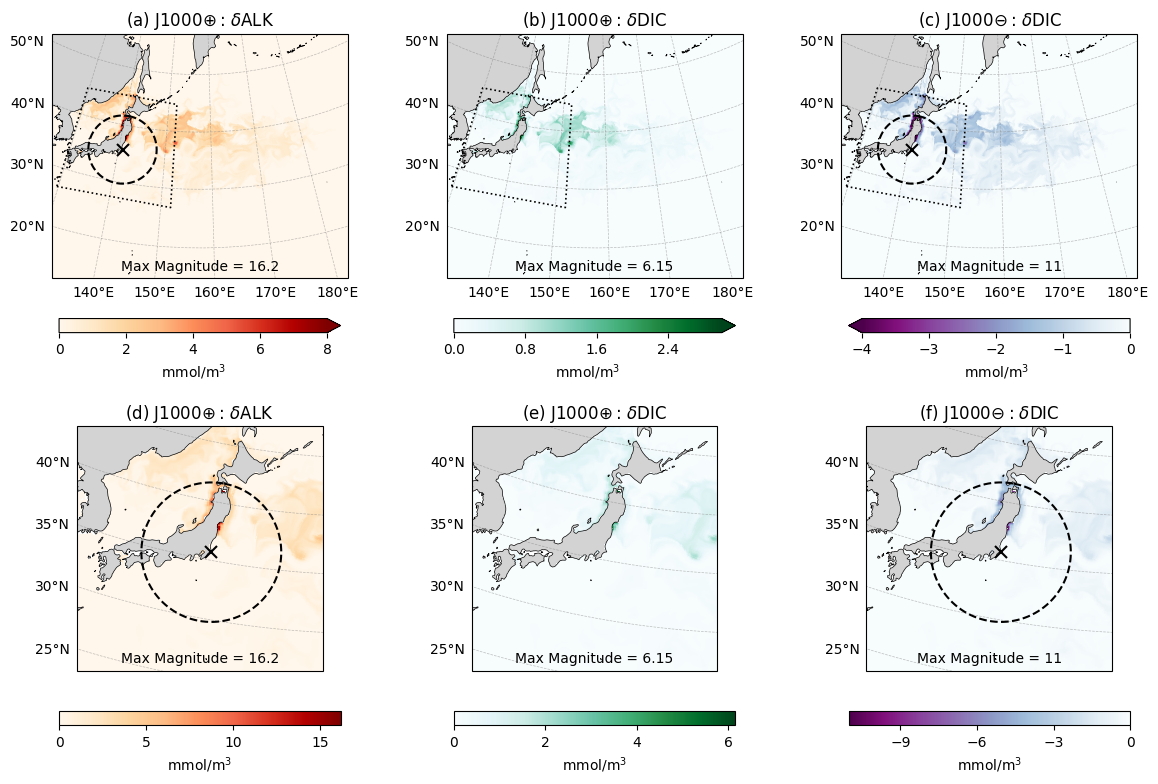

In [16]:
fig = plot_truth_panel(
    "20000701", "JP8",
    kwargs_override={
        "alk_oae": dict(vmin=0, vmax=8),
        "dic_oae": dict(vmin=0, vmax=3),
        "dic_dor": dict(vmin=-4, vmax=0),
    },
    release_centers=release_centers,
    zoom_row=True,
    zoom_half_width_km=1000
)

In [9]:
fig.savefig("figures/delta_alk_dic_truth_JP1000.png", dpi=300, bbox_inches="tight")

## Vancouver Island

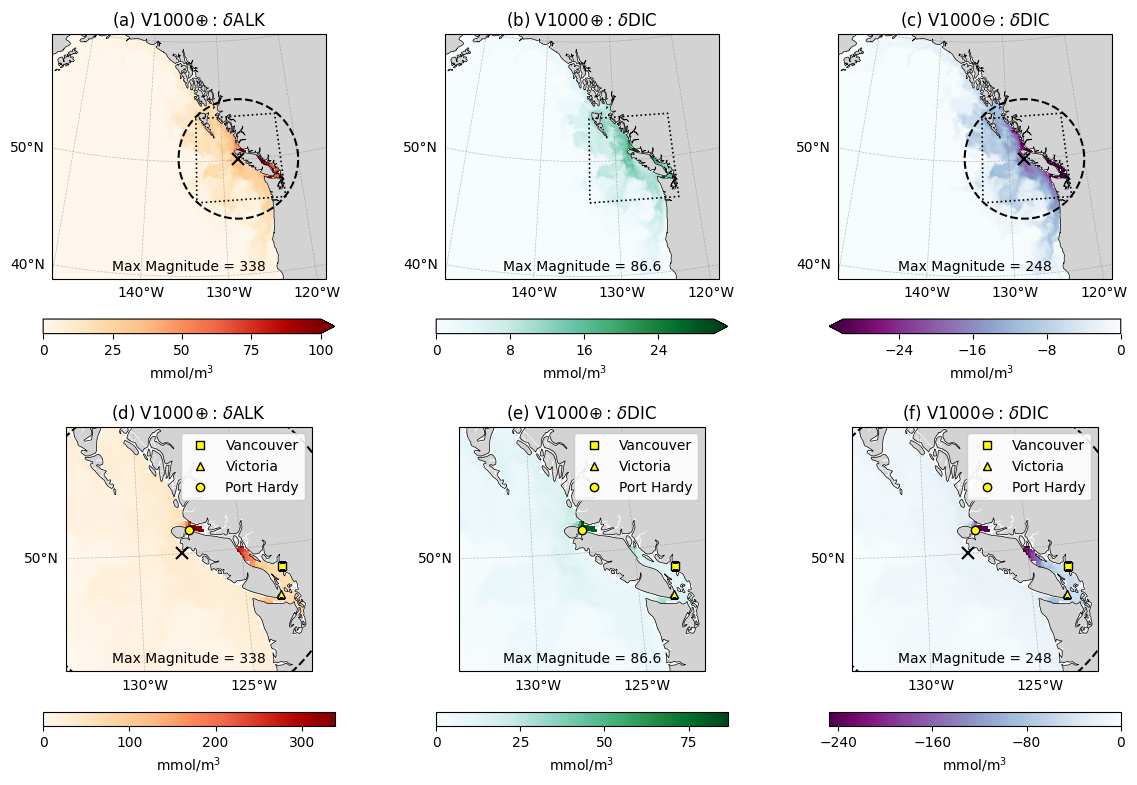

In [20]:
fig = plot_truth_panel(
    "20000701", "VI8",
    kwargs_override={
        "alk_oae": dict(vmin=0, vmax=100),
        "dic_oae": dict(vmin=0, vmax=30),
        "dic_dor": dict(vmin=-30, vmax=0),
    },
    release_centers=release_centers,
    panel_labels=("a", "b", "c"),
    zoom_row=True,
    panel_labels_zoom_row=("d", "e", "f"),
)

In [21]:
fig.savefig("figures/delta_alk_dic_truth_VI1000.png", dpi=300, bbox_inches="tight")

## Baja California

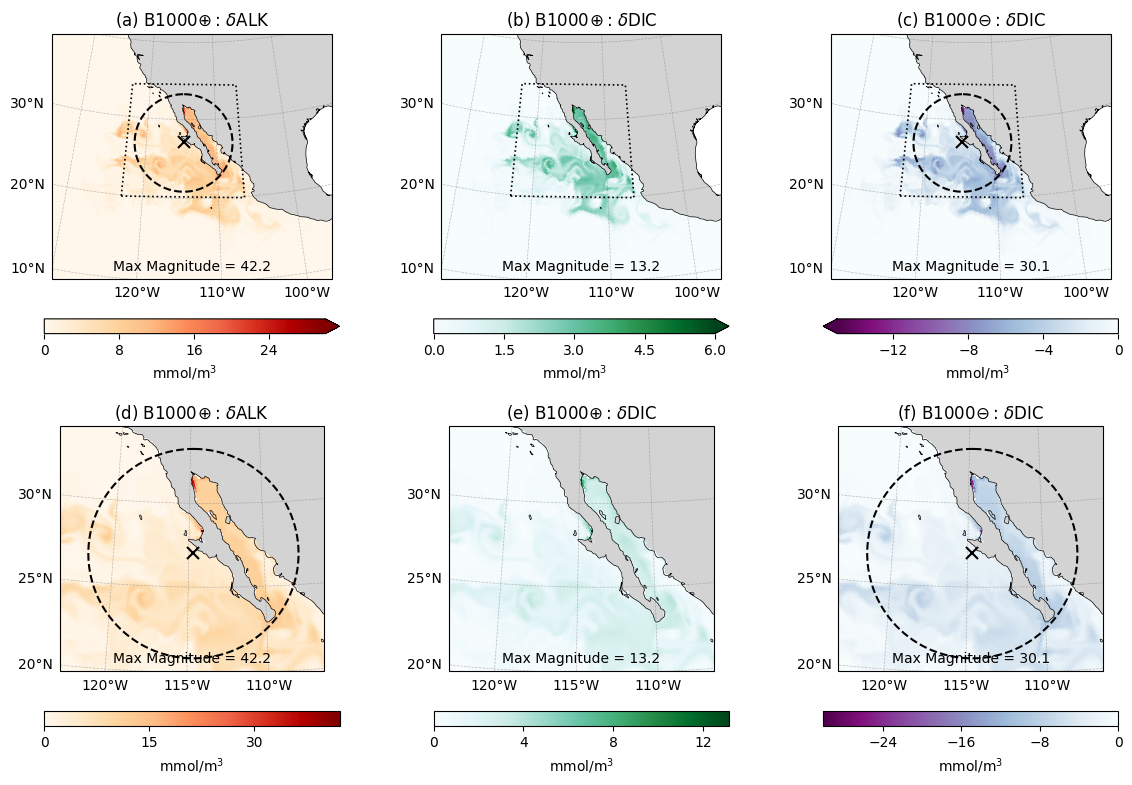

In [14]:
fig = plot_truth_panel(
    "20000701", "BC8",
    kwargs_override={
        "alk_oae": dict(vmin=0, vmax=30),
        "dic_oae": dict(vmin=0, vmax=6),
        "dic_dor": dict(vmin=-15, vmax=0),
    },
    release_centers=release_centers,
    zoom_row=True,
    zoom_half_width_km=800
)

In [15]:
fig.savefig("figures/delta_alk_dic_truth_BC1000.png", dpi=300, bbox_inches="tight")

## Ecuador

### Feburary 1 2000

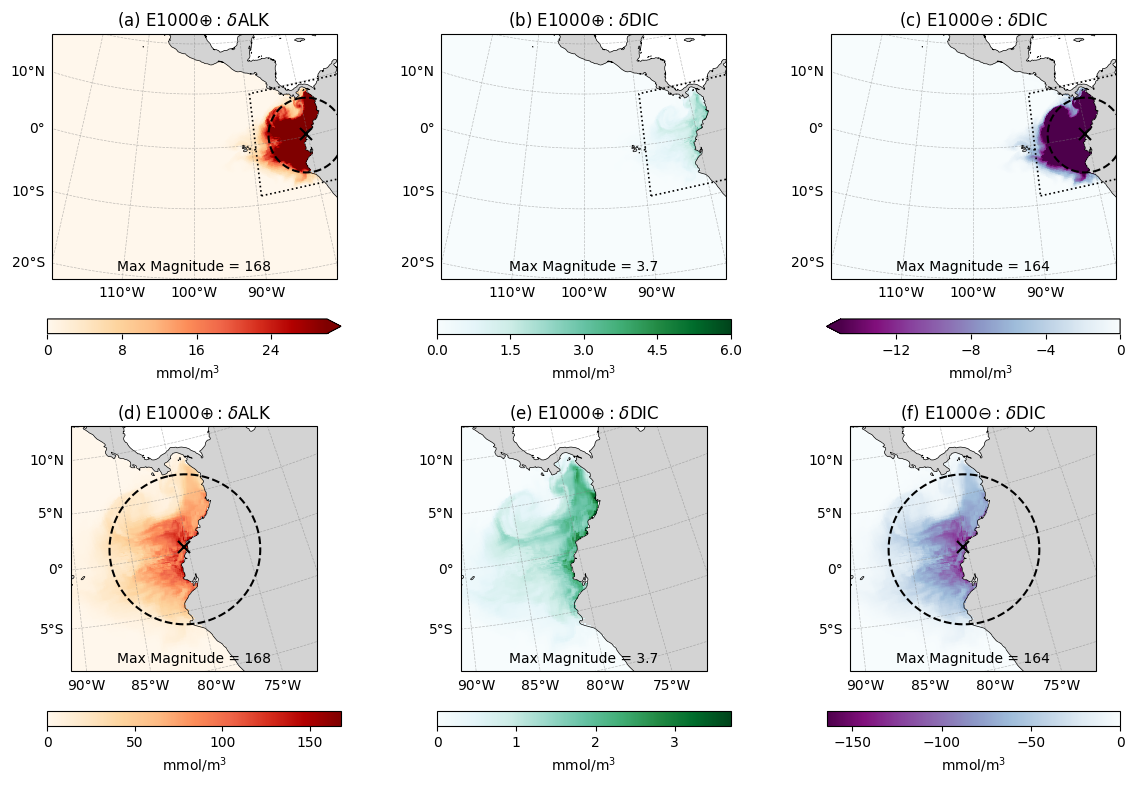

In [16]:
fig = plot_truth_panel(
    "20000201", "EC8",
    kwargs_override={
        "alk_oae": dict(vmin=0, vmax=30),
        "dic_oae": dict(vmin=0, vmax=6),
        "dic_dor": dict(vmin=-15, vmax=0),
    },
    release_centers=release_centers,
    zoom_row=True,
    zoom_half_width_km=1000
)

### April 1 2000

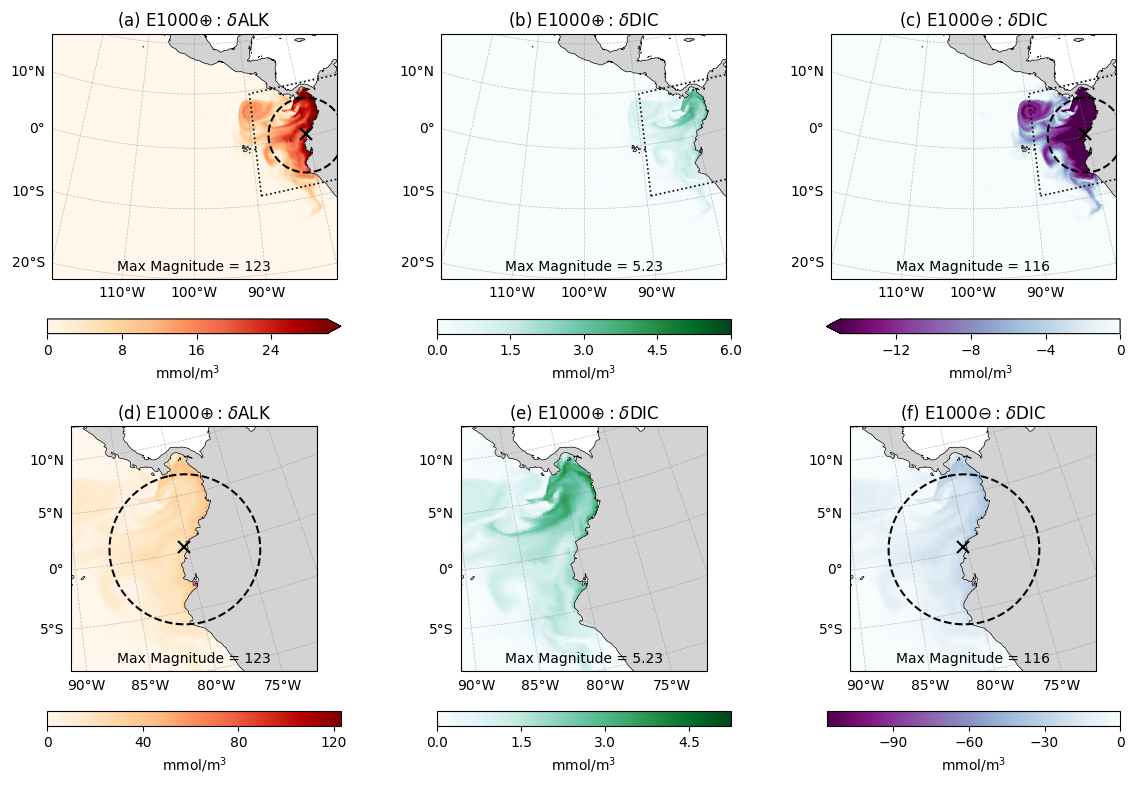

In [17]:
fig = plot_truth_panel(
    "20000401", "EC8",
    kwargs_override={
        "alk_oae": dict(vmin=0, vmax=30),
        "dic_oae": dict(vmin=0, vmax=6),
        "dic_dor": dict(vmin=-15, vmax=0),
    },
    release_centers=release_centers,
    zoom_row=True,
    zoom_half_width_km=1000
)

### July 1 2000

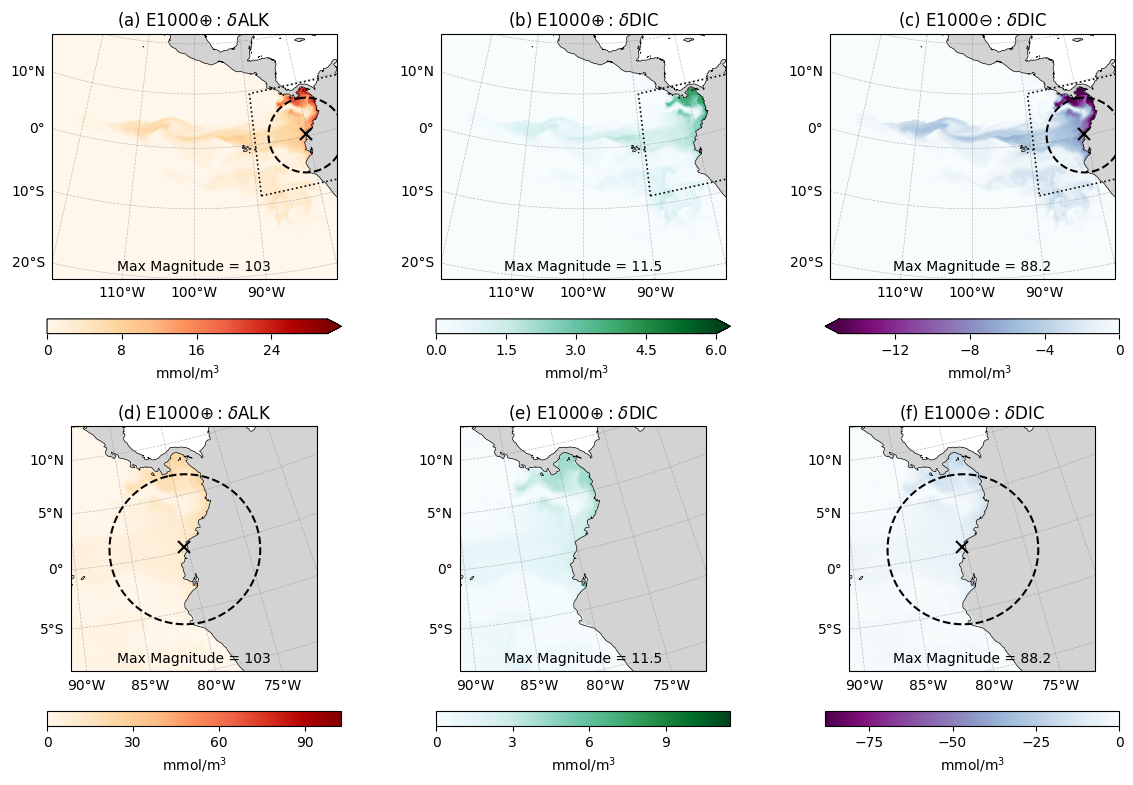

In [18]:
fig = plot_truth_panel(
    "20000701", "EC8",
    kwargs_override={
        "alk_oae": dict(vmin=0, vmax=30),
        "dic_oae": dict(vmin=0, vmax=6),
        "dic_dor": dict(vmin=-15, vmax=0),
    },
    release_centers=release_centers,
    zoom_row=True,
    zoom_half_width_km=1000
)

In [19]:
fig.savefig("figures/delta_alk_dic_truth_EC1000.png", dpi=300, bbox_inches="tight")

### December 31 2001

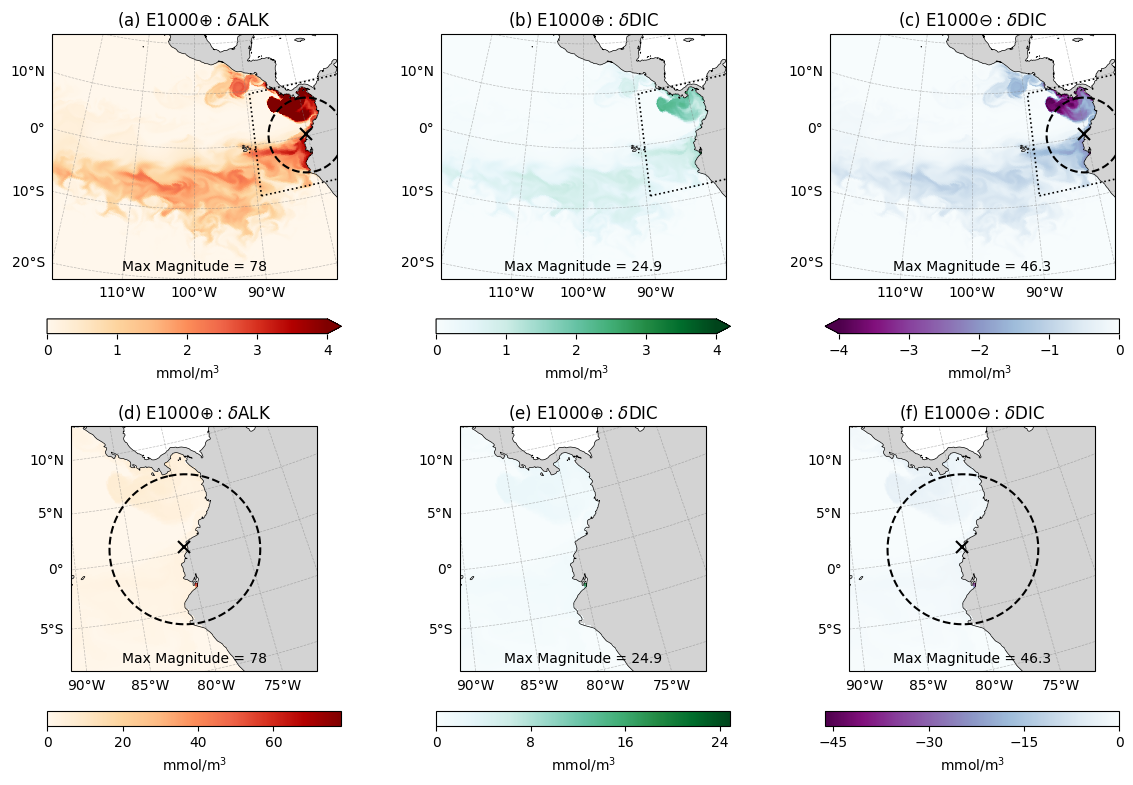

In [20]:
fig = plot_truth_panel(
    "20001231", "EC8",
    kwargs_override={
        "alk_oae": dict(vmin=0, vmax=4),
        "dic_oae": dict(vmin=0, vmax=4),
        "dic_dor": dict(vmin=-4, vmax=0),
    },
    release_centers=release_centers,
    zoom_row=True,
    zoom_half_width_km=1000
)

## $\delta$ALK only: Baja California vs. Ecuador

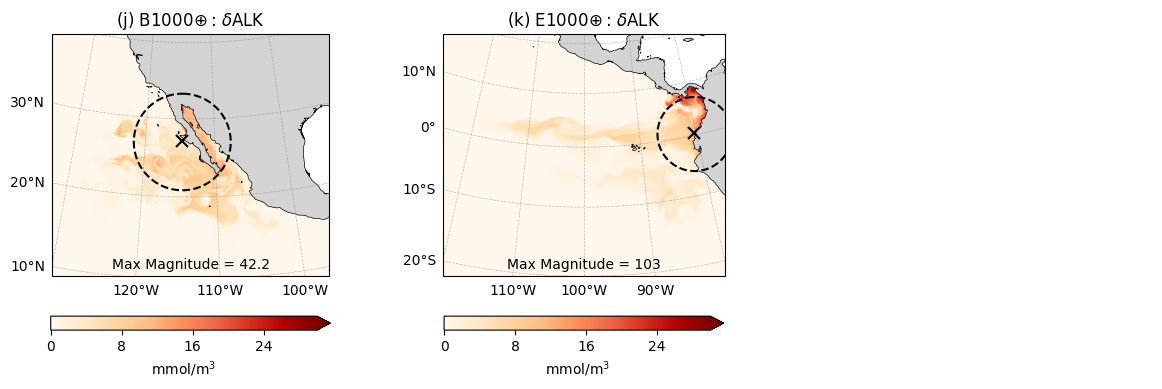

In [21]:
fig = plot_dalk_two_panel(
    "20000701", ["BC8", "EC8"],
    kwargs_override={
        "BC8": dict(vmin=0, vmax=30),
        "EC8": dict(vmin=0, vmax=30),
    },
    release_centers=release_centers,
)

In [22]:
fig.savefig("figures/delta_alk_truth_BC1000_EC1000.png", dpi=300, bbox_inches="tight")

## $\delta$ALK only: 2$\times$3 panel

Upper row: Japan, Baja California, Ecuador.
Lower row: Vancouver Island (full region with zoom box), Vancouver Island zoomed in (with city markers), empty.

In [8]:
def plot_dalk_2x3(
    date,
    upper_exps,
    lower_left_exp,
    zoom_half_width_km=400,
    zoom_cities=None,
    kwargs_override=None,
    release_centers=None,
    figsize=(14, 9),
    shrink=0.8, pad=0.12, vpos=0.05,
    upper_labels=("a", "b", "c"),
    lower_labels=("d", "e"),
    tracer="alk",
    cdr_type="oae",
):
    """2x3 figure with dALK or dDIC truth fields.

    Upper row: one panel per exp in upper_exps (length 3).
    Lower row: full-region panel for lower_left_exp (col 0, with zoom-box outline),
               zoomed-in panel with city markers (col 1), empty (col 2).
    kwargs_override keyed by exp string (or exp+"_zoom" for the zoom panel).
    tracer : "alk" or "dic" — which tracer delta to show.
    cdr_type : "oae" or "dor" — which scenario to load from.
    """
    lon, lat = grid.ds["lon_rho"], grid.ds["lat_rho"]
    cmap_key = f"{tracer}_{cdr_type}"
    var_symbol = "ALK" if tracer == "alk" else "DIC"
    if zoom_cities is None:
        loc_ll, _ = parse_exp(lower_left_exp)
        zoom_cities = DEFAULT_ZOOM_CITIES.get(loc_ll)

    # Preload data for all unique exps
    all_exps = list(upper_exps) + [lower_left_exp]
    data_cache = {}
    for exp in all_exps:
        if exp not in data_cache:
            ds = load_truth(date, cdr_type, exp)
            data_cache[exp] = compute_truth_delta(ds, tracer=tracer)

    fig = plt.figure(figsize=figsize)

    # --- Upper row ---
    for col, (exp, lbl) in enumerate(zip(upper_exps, upper_labels)):
        loc_key, _ = parse_exp(exp)
        zoom = locations[loc_key]["zoom_coords"]
        proj = ccrs.LambertConformal(
            central_longitude=(zoom["lon_min"] + zoom["lon_max"]) / 2,
            central_latitude=(zoom["lat_min"] + zoom["lat_max"]) / 2,
        )
        ax = fig.add_subplot(2, 3, col + 1, projection=proj)
        data = data_cache[exp]
        label = scenarios[cdr_type]["exps"][exp]["label"]
        title = rf"({lbl}) ${label}$: $\delta \mathrm{{{var_symbol}}}$"
        kw = {**auto_field_kwargs(data, cmap_key),
              **(kwargs_override[exp] if kwargs_override and exp in kwargs_override else {})}
        panel_rc = release_centers if release_centers else None
        plot_map_panel(fig, ax, lon, lat, data, zoom, kw,
                       shrink=shrink, pad=pad, vpos=vpos, title=title,
                       loc=loc_key, release_centers=panel_rc)

    # --- Lower row ---
    loc_ll, _ = parse_exp(lower_left_exp)
    zoom_ll = locations[loc_ll]["zoom_coords"]
    data_ll = data_cache[lower_left_exp]
    label_ll = scenarios[cdr_type]["exps"][lower_left_exp]["label"]

    # Compute the zoom sub-box for the zoom panel
    if release_centers and loc_ll in release_centers:
        lon_min_z, lon_max_z, lat_min_z, lat_max_z = compute_zoom_box(
            release_centers[loc_ll], zoom_half_width_km
        )
        zoom_sub = {"lon_min": lon_min_z, "lon_max": lon_max_z,
                    "lat_min": lat_min_z, "lat_max": lat_max_z}
        zoom_box = (lon_min_z, lon_max_z, lat_min_z, lat_max_z)
    else:
        zoom_sub = zoom_ll
        zoom_box = None

    # col 0: full region with zoom box outline
    proj_ll = ccrs.LambertConformal(
        central_longitude=(zoom_ll["lon_min"] + zoom_ll["lon_max"]) / 2,
        central_latitude=(zoom_ll["lat_min"] + zoom_ll["lat_max"]) / 2,
    )
    ax_ll = fig.add_subplot(2, 3, 4, projection=proj_ll)
    title_ll = rf"({lower_labels[0]}) ${label_ll}$: $\delta \mathrm{{{var_symbol}}}$"
    kw_ll = {**auto_field_kwargs(data_ll, cmap_key),
             **(kwargs_override[lower_left_exp] if kwargs_override and lower_left_exp in kwargs_override else {})}
    plot_map_panel(fig, ax_ll, lon, lat, data_ll, zoom_ll, kw_ll,
                   shrink=shrink, pad=pad, vpos=vpos, title=title_ll,
                   loc=loc_ll, release_centers=release_centers,
                   zoom_box=zoom_box)

    # col 1: zoomed-in panel with city markers
    proj_zoom = ccrs.LambertConformal(
        central_longitude=(zoom_sub["lon_min"] + zoom_sub["lon_max"]) / 2,
        central_latitude=(zoom_sub["lat_min"] + zoom_sub["lat_max"]) / 2,
    )
    ax_zoom = fig.add_subplot(2, 3, 5, projection=proj_zoom)
    zoom_key = lower_left_exp + "_zoom"
    kw_zoom = {**auto_field_kwargs(data_ll, cmap_key),
               **(kwargs_override[zoom_key] if kwargs_override and zoom_key in kwargs_override else {})}
    title_zoom = rf"({lower_labels[1]}) ${label_ll}$: $\delta \mathrm{{{var_symbol}}}$ (zoom)"
    plot_map_panel(fig, ax_zoom, lon, lat, data_ll, zoom_sub, kw_zoom,
                   shrink=shrink, pad=pad, vpos=vpos, title=title_zoom,
                   loc=loc_ll, release_centers=release_centers,
                   cities=zoom_cities)

    # col 2: empty
    ax_blank = fig.add_subplot(2, 3, 6)
    ax_blank.axis("off")

    plt.tight_layout()
    return fig

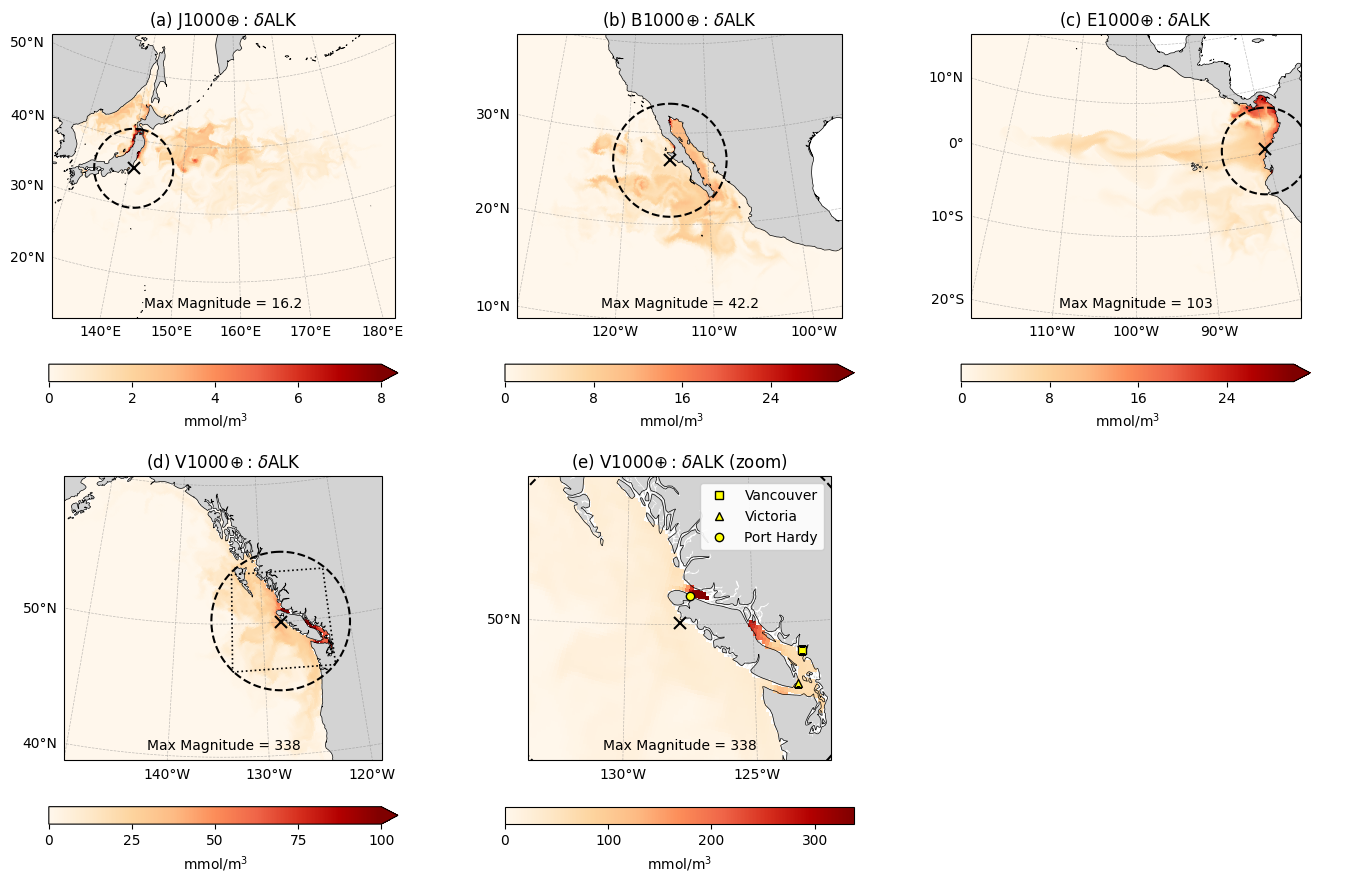

In [22]:
fig = plot_dalk_2x3(
    "20000701",
    upper_exps=["JP8", "BC8", "EC8"],
    lower_left_exp="VI8",
    zoom_half_width_km=400,
    kwargs_override={
        "JP8": dict(vmin=0, vmax=8),
        "BC8": dict(vmin=0, vmax=30),
        "EC8": dict(vmin=0, vmax=30),
        "VI8": dict(vmin=0, vmax=100),
    },
    release_centers=release_centers,
)

In [23]:
fig.savefig("figures/delta_alk_truth_2x3.png", dpi=300, bbox_inches="tight")

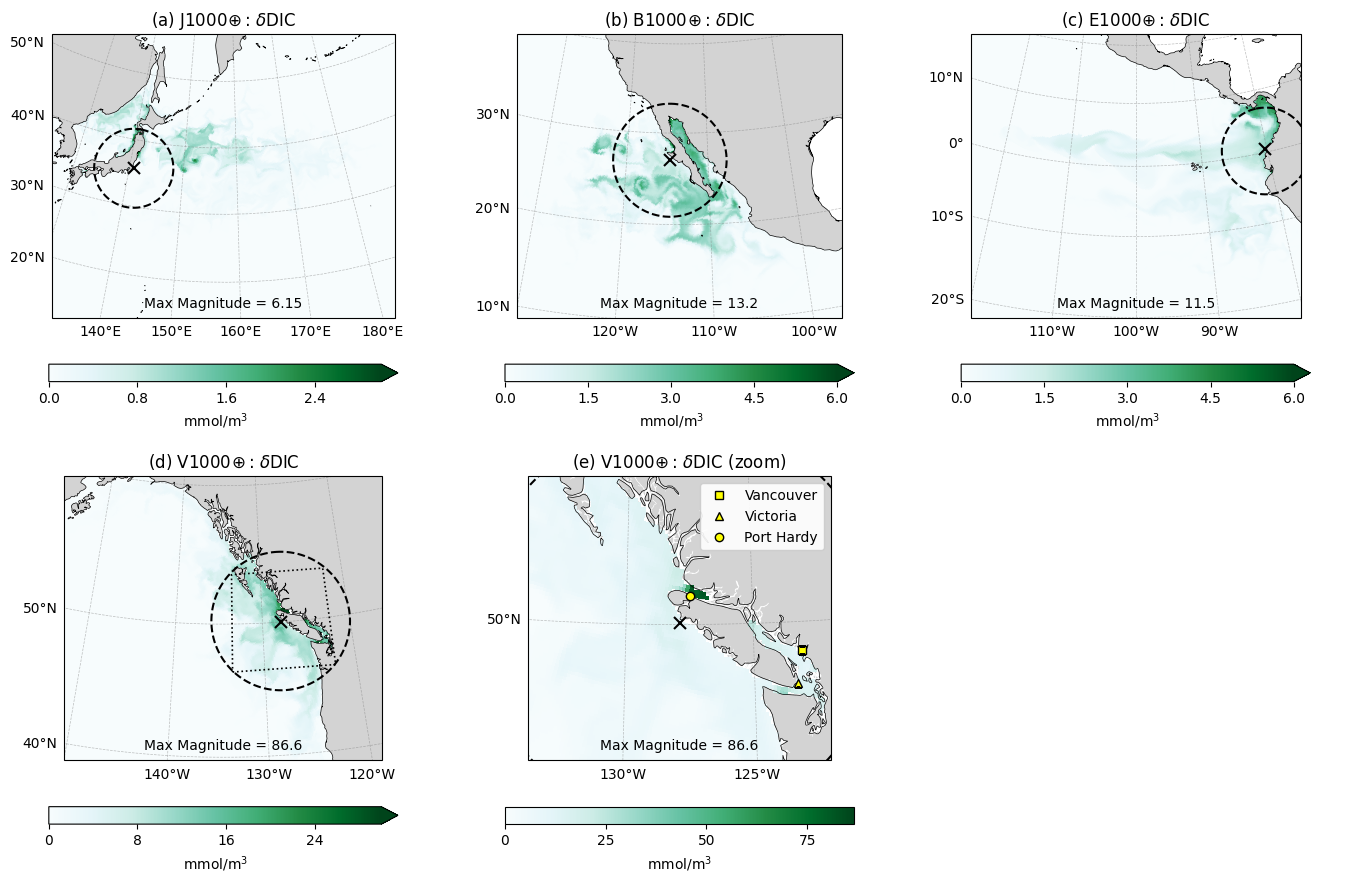

In [9]:
fig = plot_dalk_2x3(
    "20000701",
    upper_exps=["JP8", "BC8", "EC8"],
    lower_left_exp="VI8",
    zoom_half_width_km=400,
    kwargs_override={
        "JP8": dict(vmin=0, vmax=3),
        "BC8": dict(vmin=0, vmax=6),
        "EC8": dict(vmin=0, vmax=6),
        "VI8": dict(vmin=0, vmax=30),
    },
    release_centers=release_centers,
    tracer="dic", 
    cdr_type="oae"
)

In [10]:
fig.savefig("figures/delta_dic_oae_truth_2x3.png", dpi=300, bbox_inches="tight")

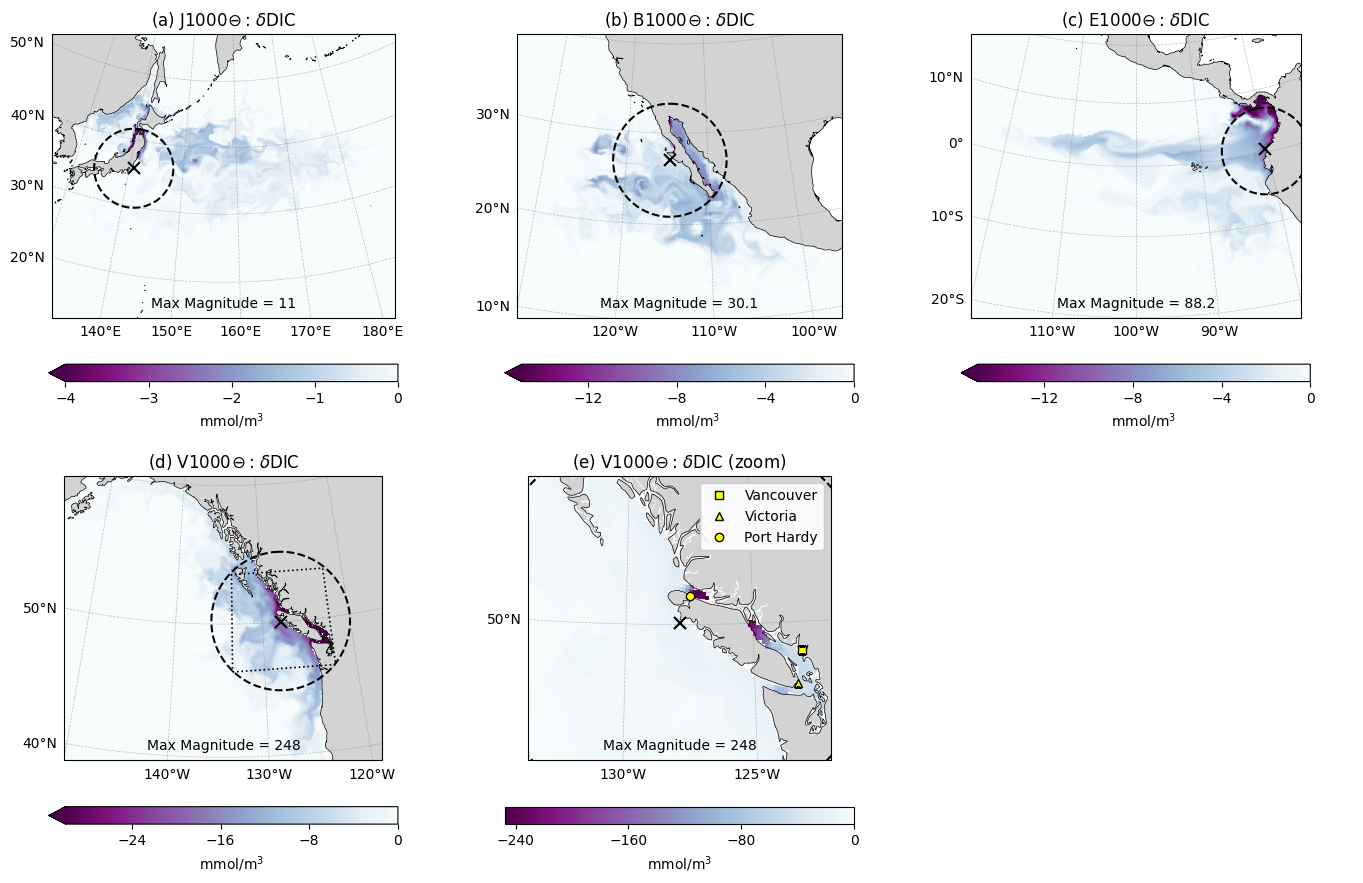

In [11]:
fig = plot_dalk_2x3(
    "20000701",
    upper_exps=["JP8", "BC8", "EC8"],
    lower_left_exp="VI8",
    zoom_half_width_km=400,
    kwargs_override={
        "JP8": dict(vmin=-4, vmax=0),
        "BC8": dict(vmin=-15, vmax=0),
        "EC8": dict(vmin=-15, vmax=0),
        "VI8": dict(vmin=-30, vmax=0),
    },
    release_centers=release_centers,
    tracer="dic", 
    cdr_type="dor"
)

In [12]:
fig.savefig("figures/delta_dic_dor_truth_2x3.png", dpi=300, bbox_inches="tight")